# Pipeline 2: Resident Progress / Intervention Priority

**Organization:** River of Life / Lighthouse Sanctuary (INTEX)  
**Methodology:** CRISP-DM–aligned (see `pipeline_guide.md`)

This notebook estimates **intervention priority risk**: whether a resident is likely to show **low educational progress or regression** in the **next ~45 days** (approximately one monthly reporting period), using only information available **before** a snapshot date.

---

## 1. Problem Framing

### Business problem
Case managers must decide **which residents need extra attention**—counseling, education support, or care planning—when time and staff are limited. Reactive firefighting after crises is costly; a **priority score** helps front-load support.

### Stakeholders
| Stakeholder | Interest |
|-------------|----------|
| **Social workers / program staff** | Who to schedule for sessions and reviews this week |
| **Leadership** | Fair workload distribution; outcomes tracking |
| **Residents** | Earlier support when patterns slip—not labels visible to youth in a stigmatizing way |

### Why this matters
Earlier, data-informed prioritization can **reduce avoidable setbacks** in schooling and wellbeing when the signals are visible in case records.

### Predictive vs explanatory
- **Predictive:** A **probability of progress risk** next period supports **scheduling and resource allocation**.
- **Explanatory:** **Logistic regression coefficients** and simple importances describe **which recorded factors co-occur** with setbacks—useful for supervision and training, not for blaming residents.

### Decision supported
**Weekly case review:** sort **Active** residents by `priority_risk_probability` and review top decile with the multidisciplinary team.

### Ethics
Models must **not** replace professional judgment. Outputs are **decision support**; sensitive attributes are used here only as in the operational dataset—deployment should follow organizational **data governance**.

---


## 2. Data Acquisition & Preparation

### Tables (joined on `resident_id`)
| Table | Use |
|-------|-----|
| `residents` | Safehouse, case status, risk level, admission date (tenure) |
| `education_records` | **Outcome:** `progress_percent`, `attendance_rate` by month |
| `health_wellbeing_records` | Recent health scores |
| `incident_reports` | Frequency and severity (last 90 days) |
| `intervention_plans` | Plan counts and stalled (`On Hold`) plans |
| `process_recordings` | Counseling/session intensity, concern flags |
| `home_visitations` | Family visit load and stressful outcomes |

### Target (operational definition)
For snapshot `as_of_date`:
1. **Baseline:** Latest `progress_percent` on or before `as_of_date`.
2. **Next period:** First education record with `record_date` in (`as_of_date`, `as_of_date + 45 days`].
3. **Positive class (`progress_risk_next_period`):**  
   `next_progress <= baseline - 3` **or** `next_progress < 45` (low absolute progress).

Rows without a qualifying **next** education record are dropped (no label).

### Leakage
All features use events with dates **≤ as_of_date** (rolling 90-day windows where noted). Labels use **future** education rows only.

### Panel correlation
Multiple rows per `resident_id` → **GroupKFold** and **grouped hold-out** by resident.

---


In [13]:
from __future__ import annotations

import json
import warnings
from datetime import timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("talk", font_scale=0.85)

RANDOM_STATE = 42
NEXT_WINDOW_DAYS = 45
REGRESS_POINTS = 3
LOW_PROGRESS_CUTOFF = 45


def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "lighthouse_csv_v7").is_dir():
            return p
    raise FileNotFoundError("lighthouse_csv_v7 not found; run from INTEX II EDA root.")


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "lighthouse_csv_v7"
OUTPUT_DIR = PROJECT_ROOT / "ml_pipelines" / "artifacts"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(PROJECT_ROOT)


/Users/jaxon/Documents/BYU Archive/Winter 2026 - Junior Core IS/INTEX II/INTEX II EDA


In [14]:
def load_tables(data_dir: Path):
    residents = pd.read_csv(
        data_dir / "residents.csv",
        parse_dates=["date_of_admission", "date_enrolled", "date_closed", "created_at"],
    )
    education = pd.read_csv(
        data_dir / "education_records.csv",
        parse_dates=["record_date"],
    )
    health = pd.read_csv(
        data_dir / "health_wellbeing_records.csv",
        parse_dates=["record_date"],
    )
    incidents = pd.read_csv(
        data_dir / "incident_reports.csv",
        parse_dates=["incident_date", "resolution_date"],
    )
    interventions = pd.read_csv(
        data_dir / "intervention_plans.csv",
        parse_dates=["created_at", "updated_at", "target_date", "case_conference_date"],
    )
    recordings = pd.read_csv(
        data_dir / "process_recordings.csv",
        parse_dates=["session_date"],
    )
    visitations = pd.read_csv(
        data_dir / "home_visitations.csv",
        parse_dates=["visit_date"],
    )
    return residents, education, health, incidents, interventions, recordings, visitations


residents_df, edu_df, health_df, inc_df, int_df, proc_df, home_df = load_tables(DATA_DIR)
print({k: v.shape for k, v in zip(
    ["residents","education","health","incidents","interventions","recordings","visitations"],
    [residents_df, edu_df, health_df, inc_df, int_df, proc_df, home_df],
)})


{'residents': (60, 49), 'education': (534, 10), 'health': (534, 14), 'incidents': (100, 12), 'interventions': (180, 11), 'recordings': (2819, 15), 'visitations': (1337, 14)}


In [15]:
SEVERITY_MAP = {"Low": 1, "Medium": 2, "High": 3}


def build_resident_panel(
    residents: pd.DataFrame,
    education: pd.DataFrame,
    health: pd.DataFrame,
    incidents: pd.DataFrame,
    interventions: pd.DataFrame,
    recordings: pd.DataFrame,
    visitations: pd.DataFrame,
    anchor_start: str = "2023-04-01",
    anchor_end: str = "2025-12-01",
) -> pd.DataFrame:
    anchors = pd.date_range(anchor_start, anchor_end, freq="MS")
    max_edu = education["record_date"].max()
    rows: list[dict] = []

    for as_of in anchors:
        if as_of + timedelta(days=NEXT_WINDOW_DAYS) > max_edu:
            continue

        for rid in education["resident_id"].unique():
            e = education[education["resident_id"] == rid].sort_values("record_date")
            past = e[e["record_date"] <= as_of]
            if past.empty:
                continue
            baseline_prog = float(past.iloc[-1]["progress_percent"])
            fut = e[
                (e["record_date"] > as_of)
                & (e["record_date"] <= as_of + timedelta(days=NEXT_WINDOW_DAYS))
            ]
            if fut.empty:
                continue
            next_prog = float(fut.iloc[0]["progress_percent"])
            y = int(
                (next_prog <= baseline_prog - REGRESS_POINTS)
                or (next_prog < LOW_PROGRESS_CUTOFF)
            )

            d0 = as_of - timedelta(days=90)
            ep = e[(e["record_date"] >= d0) & (e["record_date"] <= as_of)]
            edu_count_90d = int(len(ep))
            edu_mean_att = float(ep["attendance_rate"].mean()) if len(ep) else np.nan
            edu_mean_prog = float(ep["progress_percent"].mean()) if len(ep) else np.nan
            if len(ep) >= 2:
                edu_trend = (ep.iloc[-1]["progress_percent"] - ep.iloc[0]["progress_percent"]) / max(
                    len(ep) - 1, 1
                )
            else:
                edu_trend = 0.0

            hp = health[
                (health["resident_id"] == rid)
                & (health["record_date"] >= d0)
                & (health["record_date"] <= as_of)
            ]
            health_mean_gen = float(hp["general_health_score"].mean()) if len(hp) else np.nan

            ip = incidents[
                (incidents["resident_id"] == rid)
                & (incidents["incident_date"] >= d0)
                & (incidents["incident_date"] <= as_of)
            ]
            inc_count = int(len(ip))
            sev = ip["severity"].map(SEVERITY_MAP)
            inc_max_sev = int(sev.max()) if len(ip) and sev.notna().any() else 0
            inc_unres = int((~ip["resolved"].fillna(True)).sum()) if len(ip) else 0

            plans = interventions[
                (interventions["resident_id"] == rid)
                & (interventions["created_at"] <= as_of)
            ]
            n_plans = int(len(plans))
            on_hold = int((plans["status"] == "On Hold").sum())

            pr = recordings[
                (recordings["resident_id"] == rid)
                & (recordings["session_date"] >= d0)
                & (recordings["session_date"] <= as_of)
            ]
            sess_n = int(len(pr))
            concerns_rate = (
                float(pr["concerns_flagged"].fillna(False).astype(bool).mean()) if len(pr) else 0.0
            )

            hv = visitations[
                (visitations["resident_id"] == rid)
                & (visitations["visit_date"] >= d0)
                & (visitations["visit_date"] <= as_of)
            ]
            hv_n = int(len(hv))
            bad_out = hv["visit_outcome"].isin(["Unfavorable", "Needs Improvement"])
            hv_stress = float(bad_out.mean()) if len(hv) else 0.0

            r = residents[residents["resident_id"] == rid].iloc[0]
            admit = r["date_of_admission"]
            tenure_days = int((as_of - admit).days) if pd.notna(admit) else np.nan

            rows.append(
                {
                    "resident_id": rid,
                    "as_of_date": as_of,
                    "progress_risk_next_period": y,
                    "baseline_progress_snapshot": baseline_prog,
                    "edu_count_90d": edu_count_90d,
                    "edu_mean_attendance_90d": edu_mean_att,
                    "edu_mean_progress_90d": edu_mean_prog,
                    "edu_progress_trend_90d": float(edu_trend),
                    "health_mean_general_90d": health_mean_gen,
                    "incident_count_90d": inc_count,
                    "incident_max_severity_90d": inc_max_sev,
                    "incident_unresolved_90d": inc_unres,
                    "intervention_plan_count": n_plans,
                    "intervention_on_hold_count": on_hold,
                    "counseling_sessions_90d": sess_n,
                    "counseling_concerns_rate_90d": concerns_rate,
                    "home_visits_90d": hv_n,
                    "home_visit_stress_rate_90d": hv_stress,
                    "tenure_days": tenure_days,
                    "safehouse_id": int(r["safehouse_id"]),
                    "current_risk_level": r["current_risk_level"],
                    "case_status": r["case_status"],
                }
            )

    panel = pd.DataFrame(rows)
    for col in ["edu_mean_attendance_90d", "edu_mean_progress_90d", "health_mean_general_90d", "tenure_days"]:
        panel[col] = panel[col].fillna(panel[col].median())
    return panel


panel_df = build_resident_panel(
    residents_df, edu_df, health_df, inc_df, int_df, proc_df, home_df
)
print(panel_df.shape)
print(panel_df["progress_risk_next_period"].value_counts(normalize=True))
panel_df.head()


(461, 22)
progress_risk_next_period
0    0.874187
1    0.125813
Name: proportion, dtype: float64


,resident_id,as_of_date,progress_risk_next_period,baseline_progress_snapshot,edu_count_90d,edu_mean_attendance_90d,edu_mean_progress_90d,edu_progress_trend_90d,health_mean_general_90d,incident_count_90d,...,intervention_plan_count,intervention_on_hold_count,counseling_sessions_90d,counseling_concerns_rate_90d,home_visits_90d,home_visit_stress_rate_90d,tenure_days,safehouse_id,current_risk_level,case_status
0,2,2023-04-01,0,73.7,2,0.692000,70.250000,6.90,3.265000,0,...,3,1,0,0.000000,0,0.00,14,3,Medium,Closed
1,11,2023-04-01,1,41.4,1,0.771000,41.400000,0.00,2.930000,0,...,3,2,0,0.000000,0,0.00,0,1,Low,Closed
2,13,2023-04-01,0,75.4,3,0.652667,59.366667,15.90,3.153333,0,...,3,0,3,0.000000,4,0.25,37,2,Low,Closed
3,23,2023-04-01,0,72.1,3,0.699333,57.533333,11.05,3.163333,0,...,3,0,7,0.285714,2,0.50,44,5,Medium,Closed
4,29,2023-04-01,0,76.4,2,0.727500,73.500000,5.80,3.070000,0,...,3,1,4,0.250000,1,0.00,27,8,Medium,Transferred


### Missing values
Rolling means use **median imputation** when no health (or sparse education) rows exist in the 90-day window—documented so clinicians know zeros are not fabricated counts.

### Outliers
Continuous inputs are **not** aggressively clipped here; tree models are robust. The logistic model uses **scaling** on numeric columns.

---


## 3. Exploration (EDA)

Focus: education trajectory, incidents, and service intensity vs **next-period progress risk**.

---


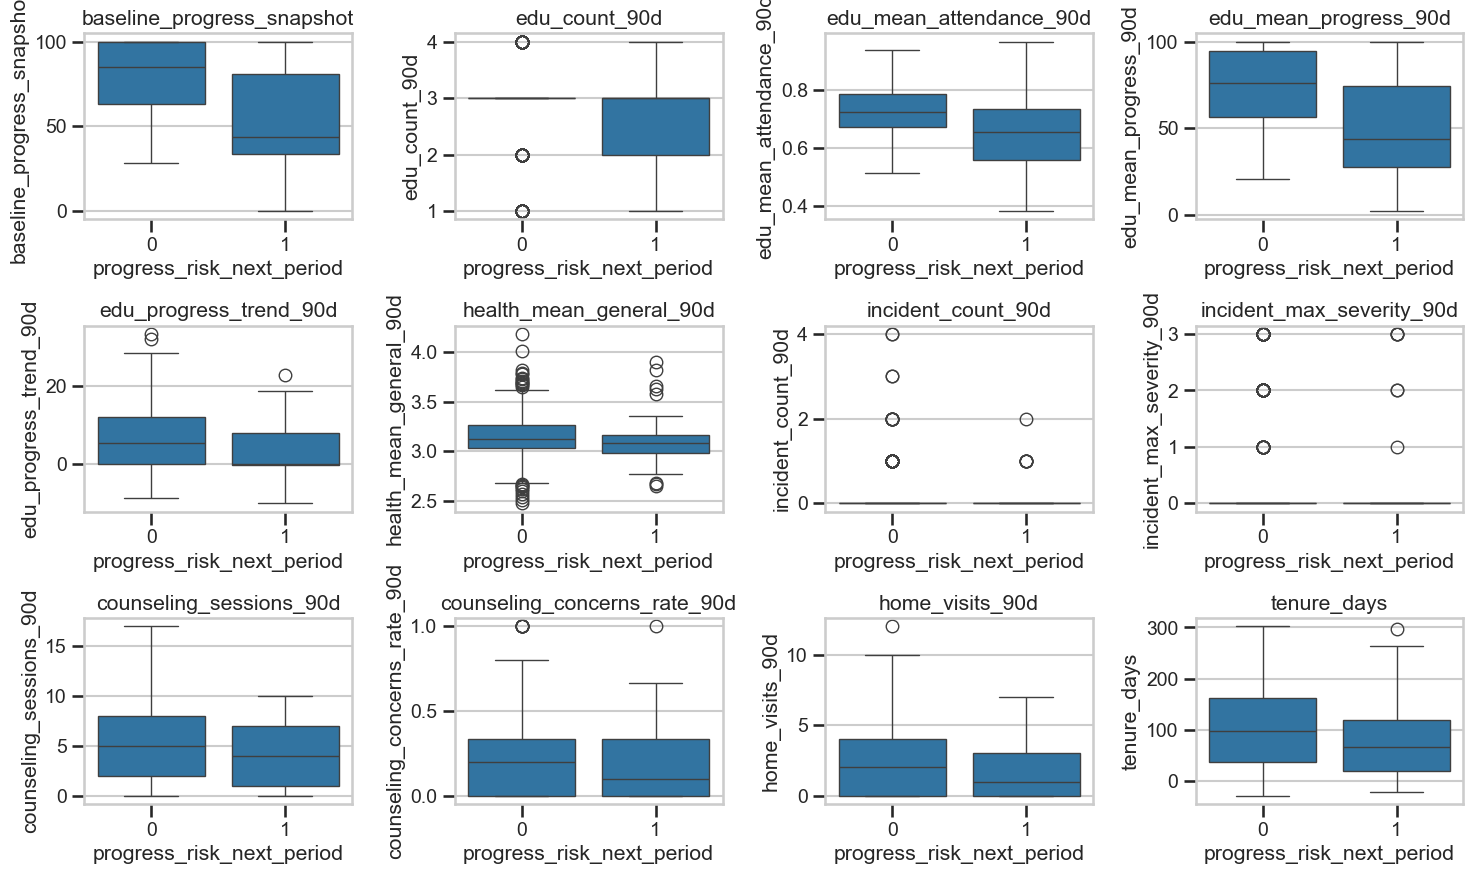

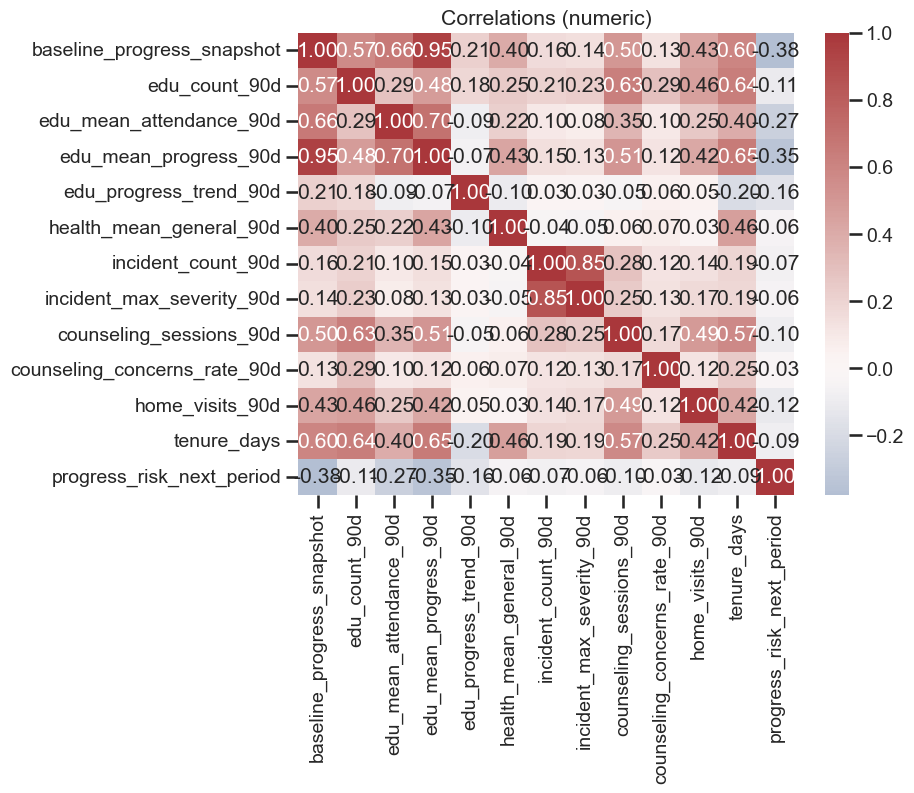

In [16]:
eda = panel_df.copy()
num_cols = [
    "baseline_progress_snapshot",
    "edu_count_90d",
    "edu_mean_attendance_90d",
    "edu_mean_progress_90d",
    "edu_progress_trend_90d",
    "health_mean_general_90d",
    "incident_count_90d",
    "incident_max_severity_90d",
    "counseling_sessions_90d",
    "counseling_concerns_rate_90d",
    "home_visits_90d",
    "tenure_days",
]

fig, axes = plt.subplots(3, 4, figsize=(15, 9))
for ax, col in zip(axes.ravel(), num_cols):
    sns.boxplot(data=eda, x="progress_risk_next_period", y=col, ax=ax)
    ax.set_title(col[:28])
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(
    eda[num_cols + ["progress_risk_next_period"]].corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
)
plt.title("Correlations (numeric)")
plt.show()


### EDA interpretation
Boxplots show **separation** (or overlap) between risk and non-risk rows. Correlations are **weak by design**—outcomes are multifactorial. The model combines signals; **do not** over-interpret single correlations as causal.

---


## 4. Modeling & Feature Selection

### Models
- **Explanatory:** `LogisticRegression(class_weight='balanced')` — signed coefficients.
- **Predictive:** `RandomForestClassifier` and `GradientBoostingClassifier` — higher capacity; may overfit on small **resident** counts.

### Feature selection
`SelectFromModel` with **L1 logistic** reduces collinear service-intensity features before a second logistic fit.

### Grouped validation
`GroupKFold` by `resident_id` (5 folds on training residents).

---


In [17]:
FEATURE_NUM = [
    "baseline_progress_snapshot",
    "edu_count_90d",
    "edu_mean_attendance_90d",
    "edu_mean_progress_90d",
    "edu_progress_trend_90d",
    "health_mean_general_90d",
    "incident_count_90d",
    "incident_max_severity_90d",
    "incident_unresolved_90d",
    "intervention_plan_count",
    "intervention_on_hold_count",
    "counseling_sessions_90d",
    "counseling_concerns_rate_90d",
    "home_visits_90d",
    "home_visit_stress_rate_90d",
    "tenure_days",
    "safehouse_id",
]
FEATURE_CAT = ["current_risk_level", "case_status"]

X = panel_df[FEATURE_NUM + FEATURE_CAT]
y = panel_df["progress_risk_next_period"]
groups = panel_df["resident_id"]

preprocess = ColumnTransformer(
    [
        ("num", StandardScaler(), FEATURE_NUM),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), FEATURE_CAT),
    ]
)


def make_pipe(est) -> Pipeline:
    return Pipeline([("prep", preprocess), ("clf", est)])


gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
tr, te = next(gss.split(X, y, groups))
X_train, X_test = X.iloc[tr], X.iloc[te]
y_train, y_test = y.iloc[tr], y.iloc[te]
g_tr = groups.iloc[tr]
print("Train", len(X_train), "residents", g_tr.nunique(), "Test", groups.iloc[te].nunique())


Train 346 residents 45 Test 15


In [18]:
models = {
    "logistic_balanced": LogisticRegression(
        max_iter=4000, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=400,
        max_depth=4,
        min_samples_leaf=8,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "gradient_boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE,
        max_depth=3,
        learning_rate=0.06,
        n_estimators=150,
    ),
}

scoring = ["roc_auc", "f1", "precision", "recall", "accuracy"]
gkf = GroupKFold(n_splits=5)
cv_rows = []
for name, est in models.items():
    pipe = make_pipe(est)
    sc = cross_validate(
        pipe, X_train, y_train, cv=gkf, groups=g_tr, scoring=scoring, n_jobs=-1
    )
    row = {"model": name}
    for m in scoring:
        row[f"{m}_mean"] = sc[f"test_{m}"].mean()
        row[f"{m}_std"] = sc[f"test_{m}"].std()
    cv_rows.append(row)

cv_summary = pd.DataFrame(cv_rows).set_index("model").sort_values("roc_auc_mean", ascending=False)
cv_summary


,roc_auc_mean,roc_auc_std,f1_mean,f1_std,precision_mean,precision_std,recall_mean,recall_std,accuracy_mean,accuracy_std
model,,,,,,,,,,
logistic_balanced,0.759609,0.101097,0.346695,0.116441,0.265495,0.079359,0.561608,0.253437,0.731139,0.037806
random_forest,0.755354,0.074166,0.501762,0.144778,0.582143,0.149090,0.475455,0.171911,0.878592,0.021789
gradient_boosting,0.736478,0.118291,0.464211,0.192553,0.621032,0.208920,0.401503,0.178423,0.884389,0.024260


In [19]:
best_name = cv_summary.index[0]
best_pipe = make_pipe(models[best_name])
best_pipe.fit(X_train, y_train)
proba = best_pipe.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)
print("Model:", best_name)
print("ROC-AUC", roc_auc_score(y_test, proba))
print(classification_report(y_test, pred, target_names=["ok_next_period", "progress_risk"], zero_division=0))


Model: logistic_balanced
ROC-AUC 0.4439252336448598
                precision    recall  f1-score   support

ok_next_period       0.92      0.78      0.84       107
 progress_risk       0.04      0.12      0.06         8

      accuracy                           0.73       115
     macro avg       0.48      0.45      0.45       115
  weighted avg       0.86      0.73      0.79       115



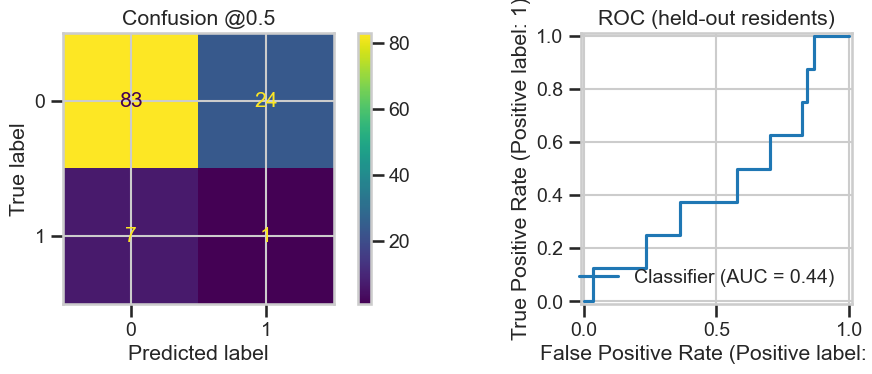

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(y_test, pred, ax=ax[0])
RocCurveDisplay.from_predictions(y_test, proba, ax=ax[1])
ax[0].set_title("Confusion @0.5")
ax[1].set_title("ROC (held-out residents)")
plt.tight_layout()
plt.show()


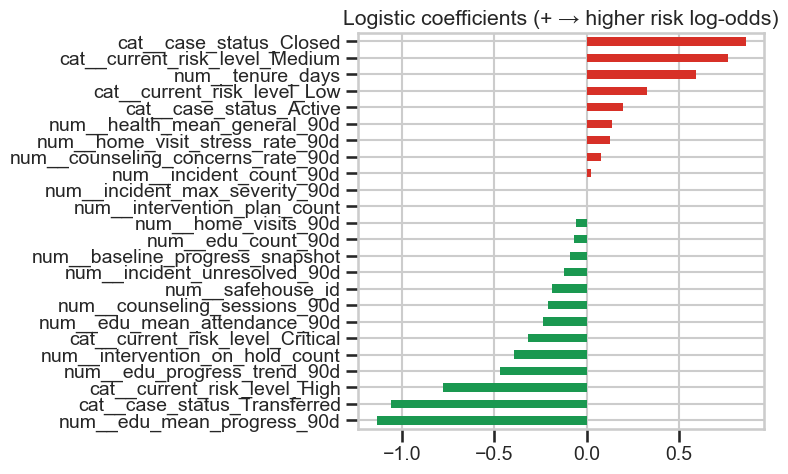

In [21]:
log_pipe = make_pipe(
    LogisticRegression(max_iter=4000, class_weight="balanced", random_state=RANDOM_STATE)
)
log_pipe.fit(X_train, y_train)
prep = log_pipe.named_steps["prep"]
coefs = pd.Series(
    log_pipe.named_steps["clf"].coef_.ravel(),
    index=prep.get_feature_names_out(),
).sort_values()

plt.figure(figsize=(8, max(5, len(coefs) * 0.2)))
coefs.plot(kind="barh", color=np.where(coefs.values < 0, "#1a9850", "#d73027"))
plt.title("Logistic coefficients (+ → higher risk log-odds)")
plt.tight_layout()
plt.show()


In [22]:
sel_pipe = Pipeline(
    [
        ("prep", preprocess),
        (
            "select",
            SelectFromModel(
                LogisticRegression(
                    penalty="l1",
                    solver="saga",
                    max_iter=6000,
                    class_weight="balanced",
                    C=0.25,
                    random_state=RANDOM_STATE,
                ),
                threshold="median",
            ),
        ),
        (
            "clf",
            LogisticRegression(
                max_iter=4000, class_weight="balanced", random_state=RANDOM_STATE
            ),
        ),
    ]
)
sel_pipe.fit(X_train, y_train)
sp = sel_pipe.predict_proba(X_test)[:, 1]
print("L1-selected logistic ROC-AUC:", roc_auc_score(y_test, sp))


L1-selected logistic ROC-AUC: 0.5046728971962617


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


## 5. Evaluation & Interpretation

### Metrics
Imbalanced positive class (~10–15%) → **ROC-AUC** and **recall** matter for catching residents who need support; **precision** matters to avoid overwhelming staff with false alarms.

### Trade-offs
- **False negative:** Resident struggles next month but flagged low → **missed support**. Prefer **higher recall** for supervision queues if capacity allows follow-up.
- **False positive:** Extra review for a resident who would have been fine → **staff time**; acceptable if review is constructive.

### Business read
Report **probability bands** (low/medium/high) rather than only a 0.5 cutoff.

---


## 6. Causal & Relationship Analysis

Associations (e.g., more incidents or concerns in 90 days **with** higher risk) are **not** proof that incidents *cause* academic slips—both may reflect an underlying difficult period.

Use coefficients as **hypothesis generators** for case conferences, not automated sanctions.

---


## 7. Deployment Plan

### PostgreSQL: `resident_progress_predictions`

```sql
CREATE TABLE IF NOT EXISTS resident_progress_predictions (
    prediction_id BIGSERIAL PRIMARY KEY,
    resident_id INTEGER NOT NULL REFERENCES residents(resident_id),
    as_of_date DATE NOT NULL,
    forecast_horizon_days INTEGER NOT NULL,
    progress_risk_probability DOUBLE PRECISION NOT NULL,
    priority_tier VARCHAR(16) NOT NULL,
    model_version VARCHAR(32) NOT NULL,
    key_drivers JSONB,
    scored_at TIMESTAMPTZ NOT NULL DEFAULT NOW(),
    UNIQUE (resident_id, as_of_date, forecast_horizon_days, model_version)
);
CREATE INDEX idx_res_prog_tier ON resident_progress_predictions (priority_tier, scored_at DESC);
```

### Data flow
`Python batch → PostgreSQL → .NET admin (case dashboard)`

### Tiering example
- **High:** p ≥ 0.55  
- **Medium:** 0.35–0.55  
- **Low:** < 0.35  

Tune to weekly supervision capacity.

---


In [23]:
from joblib import dump


def priority_tier(p: float) -> str:
    if p >= 0.55:
        return "High"
    if p >= 0.35:
        return "Medium"
    return "Low"


final = make_pipe(
    LogisticRegression(max_iter=4000, class_weight="balanced", random_state=RANDOM_STATE)
)
final.fit(X, y)

latest = panel_df["as_of_date"].max()
score_df = panel_df[panel_df["as_of_date"] == latest].copy()
Xs = score_df[FEATURE_NUM + FEATURE_CAT]
score_df["progress_risk_probability"] = final.predict_proba(Xs)[:, 1]
score_df["priority_tier"] = score_df["progress_risk_probability"].map(priority_tier)
score_df["model_version"] = "resident_progress_v1"
score_df["forecast_horizon_days"] = NEXT_WINDOW_DAYS

out_cols = [
    "resident_id",
    "as_of_date",
    "forecast_horizon_days",
    "progress_risk_probability",
    "priority_tier",
    "model_version",
    "safehouse_id",
    "case_status",
]
preview = score_df[out_cols].sort_values("progress_risk_probability", ascending=False)
dump(final, OUTPUT_DIR / "resident_progress_model.joblib")
preview.head(15)


,resident_id,as_of_date,forecast_horizon_days,progress_risk_probability,priority_tier,model_version,safehouse_id,case_status
460,40,2025-12-01,45,0.656415,High,resident_progress_v1,1,Active


In [24]:
recs = preview.head(5).to_dict(orient="records")
for r in recs:
    r["as_of_date"] = str(r["as_of_date"].date())
with open(OUTPUT_DIR / "resident_progress_sample.jsonl", "w") as f:
    for r in recs:
        f.write(json.dumps(r, default=str) + chr(10))
print("Saved joblib + sample jsonl under ml_pipelines/artifacts/")


Saved joblib + sample jsonl under ml_pipelines/artifacts/


**End of Pipeline 2.**
